# Data gathering and preprocessing

## Imports

In [95]:
import kagglehub
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download latest version
# kagglehub.dataset_download("jessemostipak/hotel-booking-demand", output_dir="./Dataset")
# ds = pd.read_csv("./Dataset/hotel_bookings.csv").sample(10000, random_state=268555)
ds = pd.read_csv("./Dataset/hotel_bookings.csv")

## Data checks

### Understanding given data

In [96]:
ds.info()

def printMissingDataSummary(ds):
    missingCount = ds.isna().sum()
    missingPercentage = (missingCount / len(ds) * 100).round(2)

    missingSummary = pd.DataFrame({
        "missingCount": missingCount,
        "missingPercentage": missingPercentage
    })

    print("\nMissing data summary:")
    print(missingSummary)

printMissingDataSummary(ds)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### Dealing with missing data #1

In [97]:
ds.drop(columns=["company"], inplace=True)
ds.drop(columns=["is_canceled"], inplace=True)
ds = ds.loc[ds["country"].notna()].copy()
ds = ds.loc[ds["children"].notna()].copy()

### Dealing with strings (labeled as objects) in data

In [98]:
ds.describe(include="object")

ds["reservation_status_date"] = pd.to_datetime(ds["reservation_status_date"], errors="coerce")

month_map = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12,
}
ds["arrival_date_month"] = ds["arrival_date_month"].map(month_map)

for col in ds.select_dtypes(include=['object']).columns:
    if col != 'reservation_status_date':
        ds[col] = ds[col].astype('category').cat.codes

ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118898 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           118898 non-null  int8          
 1   lead_time                       118898 non-null  int64         
 2   arrival_date_year               118898 non-null  int64         
 3   arrival_date_month              118898 non-null  int64         
 4   arrival_date_week_number        118898 non-null  int64         
 5   arrival_date_day_of_month       118898 non-null  int64         
 6   stays_in_weekend_nights         118898 non-null  int64         
 7   stays_in_week_nights            118898 non-null  int64         
 8   adults                          118898 non-null  int64         
 9   children                        118898 non-null  float64       
 10  babies                          118898 non-null  int64       

### Dealing with time in data

In [99]:
ds['arrival_date'] = pd.to_datetime(
    ds['arrival_date_year'].astype(str) + '-' +
    ds['arrival_date_month'].astype(str) + '-' +
    ds['arrival_date_day_of_month'].astype(str),
    errors='coerce'
)

if 'reservation_status' in ds.columns:
    checkOutDf = ds.loc[ds['reservation_status'] == 'Check-Out'].copy()

    checkOutDf['days_diff'] = (
        checkOutDf['reservation_status_date'] - checkOutDf['arrival_date']
    ).dt.days
    checkOutDf['expected_nights'] = (
        checkOutDf['stays_in_week_nights'] + checkOutDf['stays_in_weekend_nights']
    )
    checkOutDf['is_valid_stay'] = checkOutDf['days_diff'] == checkOutDf['expected_nights']

    invalidRows = checkOutDf.loc[~checkOutDf['is_valid_stay']].copy()

    if not invalidRows.empty:
        ds = ds.drop(index=invalidRows.index).copy()
        print(f"Dropped invalid rows: {len(invalidRows)}")

ds = ds[ds['arrival_date'].notna()].copy()

ds.drop(columns=['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month'], inplace=True)



### Dealing with orphans

In [100]:
ds = ds[ds['adults'] != 0]

### Dealing with missing data #2

In [101]:
trainDf = ds[ds["agent"].notna()].copy()
predictDf = ds[ds["agent"].isna()].copy()

y = trainDf["agent"]
X = trainDf.drop(columns=["agent"])
predX = predictDf.drop(columns=["agent"])

catCols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numCols = X.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", sklearn.preprocessing.OneHotEncoder(handle_unknown="ignore"), catCols),
        ("num", "passthrough", numCols),
    ]
)

model = sklearn.pipeline.Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=268555))
])

trainX, valX, trainY, valY = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=268555)

model.fit(trainX, trainY)
print("val score:", model.score(valX, valY))

predictedAgents = model.predict(predX)

ds.loc[ds["agent"].isna(), "agent"] = predictedAgents

val score: 0.8836404406746612


In [102]:
printMissingDataSummary(ds)


Missing data summary:
                                missingCount  missingPercentage
hotel                                      0                0.0
lead_time                                  0                0.0
arrival_date_week_number                   0                0.0
stays_in_weekend_nights                    0                0.0
stays_in_week_nights                       0                0.0
adults                                     0                0.0
children                                   0                0.0
babies                                     0                0.0
meal                                       0                0.0
country                                    0                0.0
market_segment                             0                0.0
distribution_channel                       0                0.0
is_repeated_guest                          0                0.0
previous_cancellations                     0                0.0
previous_bookings

In [103]:
def printColumnValueCounts(ds):
    print(ds.nunique(dropna=False))

    rows = []
    for col in ds.columns:
        counts = ds[col].value_counts(dropna=False).sort_values(ascending=False)
        for val, cnt in counts.items():
            rows.append({
                "column": col,
                "value": str(val),
                "count": cnt
            })

    result = pd.DataFrame(rows)
    result.to_csv("./Dataset/column_value_counts.csv", index=False, encoding="utf-8-sig")
    print("Wrote", len(result), "rows to column_value_counts.csv")

printColumnValueCounts(ds)

hotel                                2
lead_time                          479
arrival_date_week_number            53
stays_in_weekend_nights             15
stays_in_week_nights                31
adults                              13
children                             5
babies                               5
meal                                 5
country                            177
market_segment                       7
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                   9
assigned_room_type                  11
booking_changes                     19
deposit_type                         3
agent                              332
days_in_waiting_list               127
customer_type                        4
adr                               8850
required_car_parking_spaces          5
total_of_special_requests            6
reservation_status       

### Correlation matrix presentation

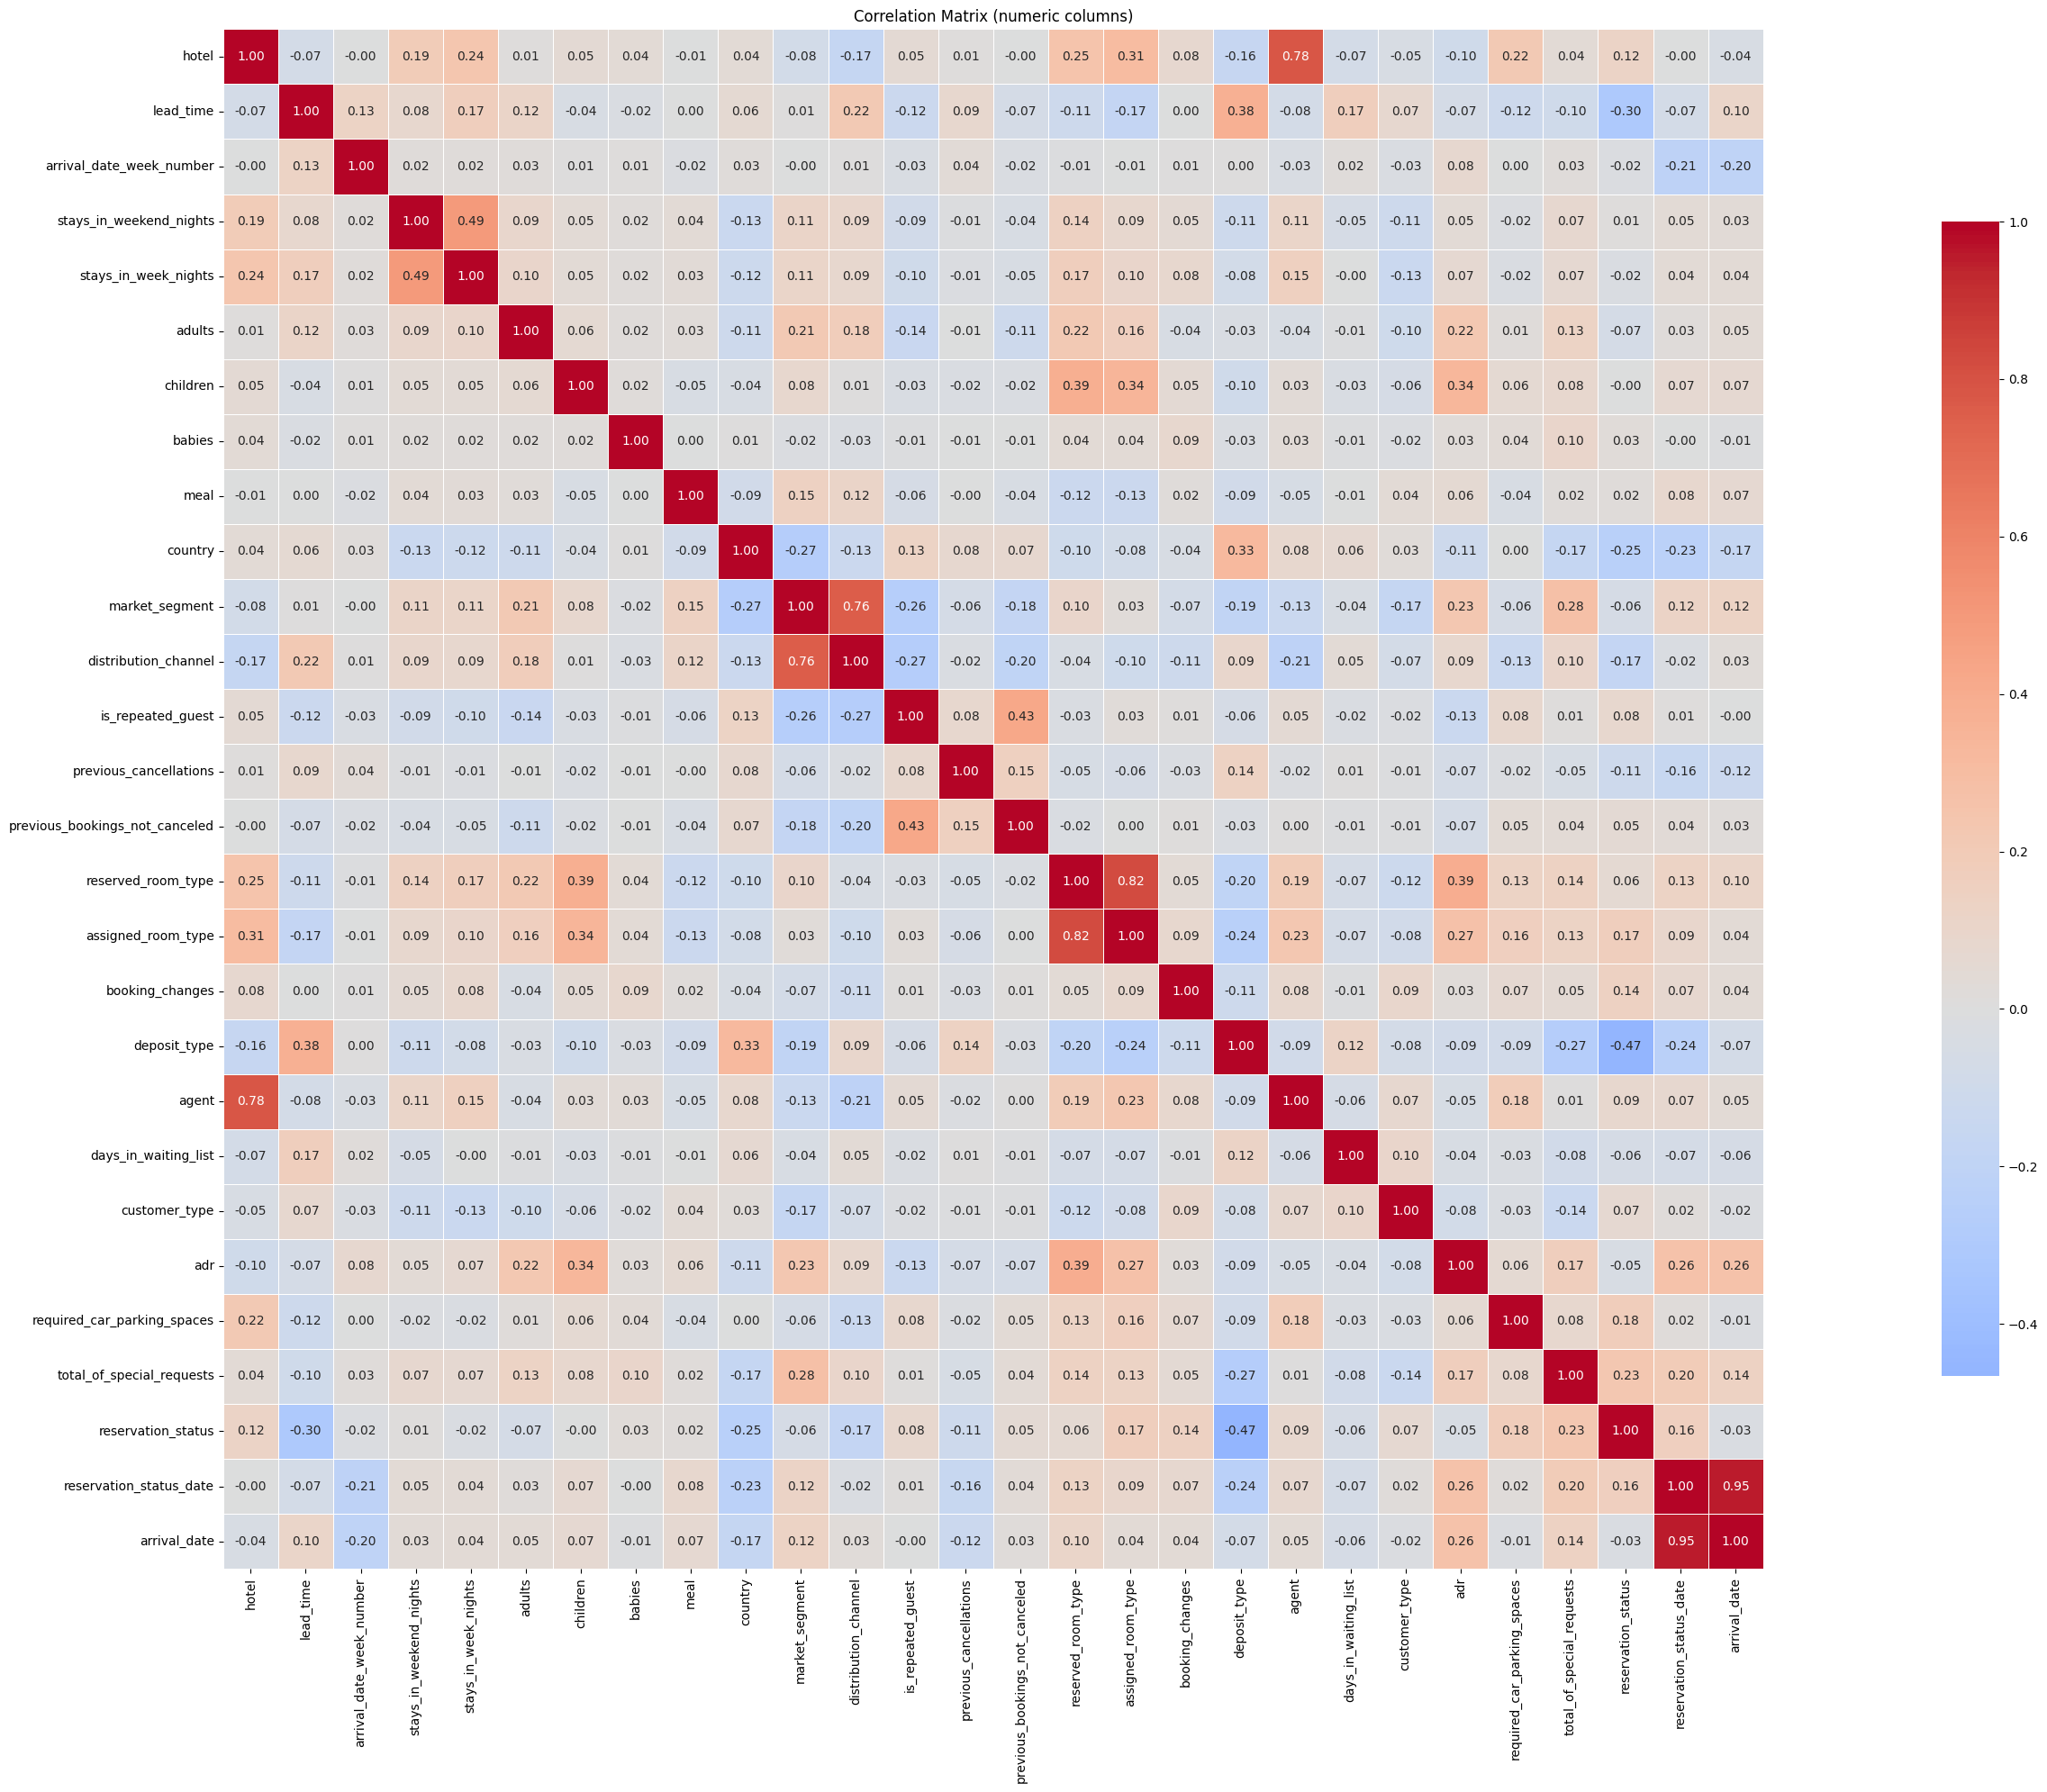

In [104]:
def printComputationMatrix(ds):
    corr = ds.corr()

    plt.figure(figsize=(40, 20))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.75}
    )
    plt.title("Correlation Matrix (numeric columns)")
    plt.tight_layout()
plt.show()

printComputationMatrix(ds)